---
title: Data Preparation & Outlier Analysis
date: 2026-09-08
---

# Data Preparation & Outlier Analysis

Tahap **Data Preparation** dalam kerangka kerja **CRISP-DM** berfokus pada konstruksi dataset akhir dari data mentah hasil penginderaan jauh (*satellite remote sensing*) Sentinel-5P untuk wilayah **Teluk Dalam, Nias Selatan**. Tahap ini mencakup pemuatan data, visualisasi lokasi **Area of Interest (AOI)** dengan `folium`, imputasi missing values, identifikasi dan penanganan outlier (IQR Capping), komparasi deteksi outlier (IQR vs Z-Score), serta ekstraksi fitur deret waktu menggunakan **TSFEL**.

### 1. Pemuatan Dataset Mentah dan Visualisasi Area of Interest (AOI) Menggunakan Folium

Dataset mentah memuat parameter konsentrasi polutan udara harian (`CO`, `NO2`, `SO2`, `CH4`) hasil ekstraksi Sentinel-5P di kawasan **Teluk Dalam, Kabupaten Nias Selatan, Sumatera Utara**.
Batas wilayah AOI ditentukan melalui berkas GeoJSON `coordinates_telukdalam.json` dengan rentang koordinat:
- **Bujur (Longitude)**: $97.8085542^{\circ}\text{E} \dots 97.8311628^{\circ}\text{E}$
- **Lintang (Latitude)**: $0.5569268^{\circ}\text{N} \dots 0.5790399^{\circ}\text{N}$

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

# Penentuan otomatis root directory proyek
def get_project_root():
    curr = os.path.abspath(os.getcwd())
    while curr != os.path.dirname(curr):
        if os.path.exists(os.path.join(curr, 'myst.yml')) or os.path.exists(os.path.join(curr, '.git')):
            return curr
        curr = os.path.dirname(curr)
    return os.path.abspath(os.getcwd())

PROJECT_ROOT = get_project_root()
DATA_DIR = os.path.join(PROJECT_ROOT, "data")

# 1. Auto-detect file dataset restrukturisasi Teluk Dalam
kandidat_file = [f for f in os.listdir(DATA_DIR) 
                 if f.startswith('data_kualitas_udara_telukdalam_restructur') and f.endswith('.csv')]

if not kandidat_file:
    raise FileNotFoundError("File CSV Teluk Dalam tidak ditemukan di folder data.")

file_path = os.path.join(DATA_DIR, kandidat_file[0])
print(f"[INFO] Dataset ditemukan: '{file_path}'")

# Load dataset mentah
df_raw = pd.read_csv(file_path)
df_raw["DATE_TIME"] = pd.to_datetime(df_raw["DATE_TIME"], errors="coerce")

# 2. Load file koordinat AOI Teluk Dalam
coord_file = os.path.join(DATA_DIR, "coordinates_telukdalam.json")
with open(coord_file, 'r') as f:
    aoi_geojson = json.load(f)

print("[INFO] Koordinat AOI GeoJSON terintegrasi berhasil dimuat.")
print(f"[INFO] Jumlah Baris Dataset: {len(df_raw)} hari | Rentang Waktu: {df_raw['DATE_TIME'].min().strftime('%Y-%m-%d')} s/d {df_raw['DATE_TIME'].max().strftime('%Y-%m-%d')}")


[INFO] Dataset ditemukan: 'C:\PSD-B\data\data_kualitas_udara_telukdalam_restructured.csv'
[INFO] Koordinat AOI GeoJSON terintegrasi berhasil dimuat.
[INFO] Jumlah Baris Dataset: 366 hari | Rentang Waktu: 2025-08-30 s/d 2026-08-30


In [2]:
# Visualisasi Peta AOI Teluk Dalam Menggunakan Folium
coords = aoi_geojson['coordinates'][0]
# Konversi koordinat [lon, lat] menjadi [lat, lon] untuk Folium
polygon_latlon = [[c[1], c[0]] for c in coords]

# Hitung titik pusat AOI
center_lat = sum(c[1] for c in coords) / len(coords)
center_lon = sum(c[0] for c in coords) / len(coords)

# Inisialisasi Peta Interaktif Folium
m = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles='OpenStreetMap')

# Tambahkan Polygon Bounding Box AOI
folium.Polygon(
    locations=polygon_latlon,
    color='red',
    weight=3,
    fill=True,
    fill_color='orange',
    fill_opacity=0.35,
    popup="<b>AOI Satellite Sentinel-5P</b><br>Teluk Dalam, Nias Selatan",
    tooltip="Area of Interest (AOI) Teluk Dalam"
).add_to(m)

# Tambahkan Marker Pusat Stasiun/Pengamatan
folium.Marker(
    location=[center_lat, center_lon],
    popup="<b>Stasiun/Pusat AOI Teluk Dalam</b><br>Lat: {:.4f}, Lon: {:.4f}".format(center_lat, center_lon),
    icon=folium.Icon(color='red', icon='info-sign')
).add_to(m)

# Simpan peta ke HTML
map_save_path = os.path.join(DATA_DIR, 'aoi_telukdalam_map.html')
m.save(map_save_path)
print(f"[INFO] Peta AOI Folium berhasil disimpan ke '{map_save_path}'")

# Tampilkan peta interaktif di notebook
m


[INFO] Peta AOI Folium berhasil disimpan ke 'C:\PSD-B\data\aoi_telukdalam_map.html'


--- 

### 2. Identifikasi dan Penanganan Missing Values Menggunakan Teknik Imputasi (Interpolasi Linear)

Data penginderaan jauh satelit sering kali memiliki missing values akibat tutupan awan (*cloud cover*), ketidaktersediaan lintasan satelit, atau gangguan atmosferik. 
Di bawah ini dilakukan identifikasi mendetail mengenai **jumlah dan tanggal spesifik kejadian missing values** untuk seluruh parameter polutan (`CO`, `NO2`, `SO2`, `CH4`), diikuti proses imputasi menggunakan **Interpolasi Linear** disertai *backward fill* (`bfill`) dan *forward fill* (`ffill`) untuk menangani nilai kosong di batas awal/akhir deret waktu.

In [3]:
# 1. Identifikasi Tanggal dan Jumlah Missing Values per Polutan
pollutants = ['CO', 'NO2', 'SO2', 'CH4']
missing_summary = []
missing_dates_dict = {}

print("=== IDENTIFIKASI KEJADIAN MISSING VALUES PER POLUTAN ===")
for pol in pollutants:
    m_mask = df_raw[pol].isna()
    m_count = m_mask.sum()
    m_dates = df_raw.loc[m_mask, 'DATE_TIME'].dt.strftime('%Y-%m-%d').tolist()
    missing_dates_dict[pol] = m_dates
    pct_missing = (m_count / len(df_raw)) * 100
    
    missing_summary.append({
        'Polutan': pol,
        'Jumlah Data Kosong': m_count,
        'Persentase Kosong (%)': f"{pct_missing:.2f}%",
        'Jumlah Data Ada': len(df_raw) - m_count
    })
    
    print(f"\n[POLUTAN: {pol}]")
    print(f"  - Total Missing Values: {m_count} dari {len(df_raw)} hari ({pct_missing:.2f}%)")
    if m_count > 0:
        print(f"  - Daftar Tanggal Kejadian Missing (Contoh 10 Pertama): {m_dates[:10]}")
        if len(m_dates) > 10:
            print(f"    ... dan {len(m_dates)-10} tanggal lainnya.")

# Tabel Ringkasan Missing Values
df_missing_summary = pd.DataFrame(missing_summary)
print("\n--- Ringkasan Statistik Missing Values ---")
print(df_missing_summary.to_string(index=False))

# 2. Eksekusi Imputasi Interpolasi Linear untuk Semua Polutan
df_imputed = df_raw.copy()
for pol in pollutants:
    df_imputed[pol] = df_imputed[pol].interpolate(method='linear').bfill().ffill()

print("\n=== VERIFIKASI HASIL IMPUTASI MISSING VALUES ===")
print("Sisa Missing Values Pasca Imputasi:")
print(df_imputed[pollutants].isna().sum())
print("[SUCCESS] Seluruh missing values pada dataset berhasil ter-imputasi sempurna (0 NaN)!")


=== IDENTIFIKASI KEJADIAN MISSING VALUES PER POLUTAN ===

[POLUTAN: CO]
  - Total Missing Values: 265 dari 366 hari (72.40%)
  - Daftar Tanggal Kejadian Missing (Contoh 10 Pertama): ['2025-08-30', '2025-08-31', '2025-09-01', '2025-09-02', '2025-09-03', '2025-09-04', '2025-09-05', '2025-09-07', '2025-09-08', '2025-09-09']
    ... dan 255 tanggal lainnya.

[POLUTAN: NO2]
  - Total Missing Values: 255 dari 366 hari (69.67%)
  - Daftar Tanggal Kejadian Missing (Contoh 10 Pertama): ['2025-08-30', '2025-08-31', '2025-09-01', '2025-09-02', '2025-09-03', '2025-09-04', '2025-09-05', '2025-09-07', '2025-09-08', '2025-09-09']
    ... dan 245 tanggal lainnya.

[POLUTAN: SO2]
  - Total Missing Values: 178 dari 366 hari (48.63%)
  - Daftar Tanggal Kejadian Missing (Contoh 10 Pertama): ['2025-08-30', '2025-09-01', '2025-09-03', '2025-09-04', '2025-09-05', '2025-09-07', '2025-09-10', '2025-09-11', '2025-09-12', '2025-09-13']
    ... dan 168 tanggal lainnya.

[POLUTAN: CH4]
  - Total Missing Values: 36

--- 

### 3. Identifikasi dan Penanganan Outlier Menggunakan Metode Interquartile Range (IQR)

Outlier pada sinyal polutan udara dapat disebabkan oleh anomali cuaca ekstrem, aktivitas pembakaran mendadak, atau kesalahan sensor satelit. 
Pendekatan **Interquartile Range (IQR)** digunakan untuk mengidentifikasi nilai ekstrem dengan mendefinisikan rentang interkuartil $\text{IQR} = Q_3 - Q_1$ dan ambang batas:
- **Batas Bawah (Lower Bound)**: $Q_1 - 1.5 \times \text{IQR}$
- **Batas Atas (Upper Bound)**: $Q_3 + 1.5 \times \text{IQR}$

Berikut disajikan **jumlah outlier**, **tanggal spesifik kejadian outlier**, serta **1 grafik khusus untuk tiap polutan (total 4 grafik)** sebelum dan sesudah penanganan outlier (*IQR Capping*).

=== HASIL DETEKSI OUTLIER METODE IQR PER POLUTAN ===



[POLUTAN: CO]


  - Kuartil 1 (Q1)     : 0.026541
  - Kuartil 3 (Q3)     : 0.032218
  - IQR                : 0.005678
  - Batas Bawah        : 0.018024
  - Batas Atas         : 0.040735
  - Jumlah Outlier     : 0 hari
  - Tanggal Outlier    : Tidak ada outlier

[POLUTAN: NO2]
  - Kuartil 1 (Q1)     : 0.000001
  - Kuartil 3 (Q3)     : 0.000009
  - IQR                : 0.000007
  - Batas Bawah        : -0.000010
  - Batas Atas         : 0.000020
  - Jumlah Outlier     : 4 hari
  - Tanggal Outlier    : ['2025-10-08', '2026-02-03', '2026-05-31', '2026-07-17']

[POLUTAN: SO2]
  - Kuartil 1 (Q1)     : -0.000071
  - Kuartil 3 (Q3)     : 0.000044
  - IQR                : 0.000114
  - Batas Bawah        : -0.000242
  - Batas Atas         : 0.000215
  - Jumlah Outlier     : 13 hari
  - Tanggal Outlier    : ['2025-10-26', '2026-01-25', '2026-03-03', '2026-03-13', '2026-04-08', '2026-04-15', '2026-04-25', '2026-07-05', '2026-07-06', '2026-07-17', '2026-07-27', '2026-08-10', '2026-08-18']



[POLUTAN: CH4]
  - Kuartil 1 (Q1)     : 1892.824707
  - Kuartil 3 (Q3)     : 1892.824707
  - IQR                : 0.000000
  - Batas Bawah        : 1892.824707
  - Batas Atas         : 1892.824707
  - Jumlah Outlier     : 0 hari
  - Tanggal Outlier    : Tidak ada outlier


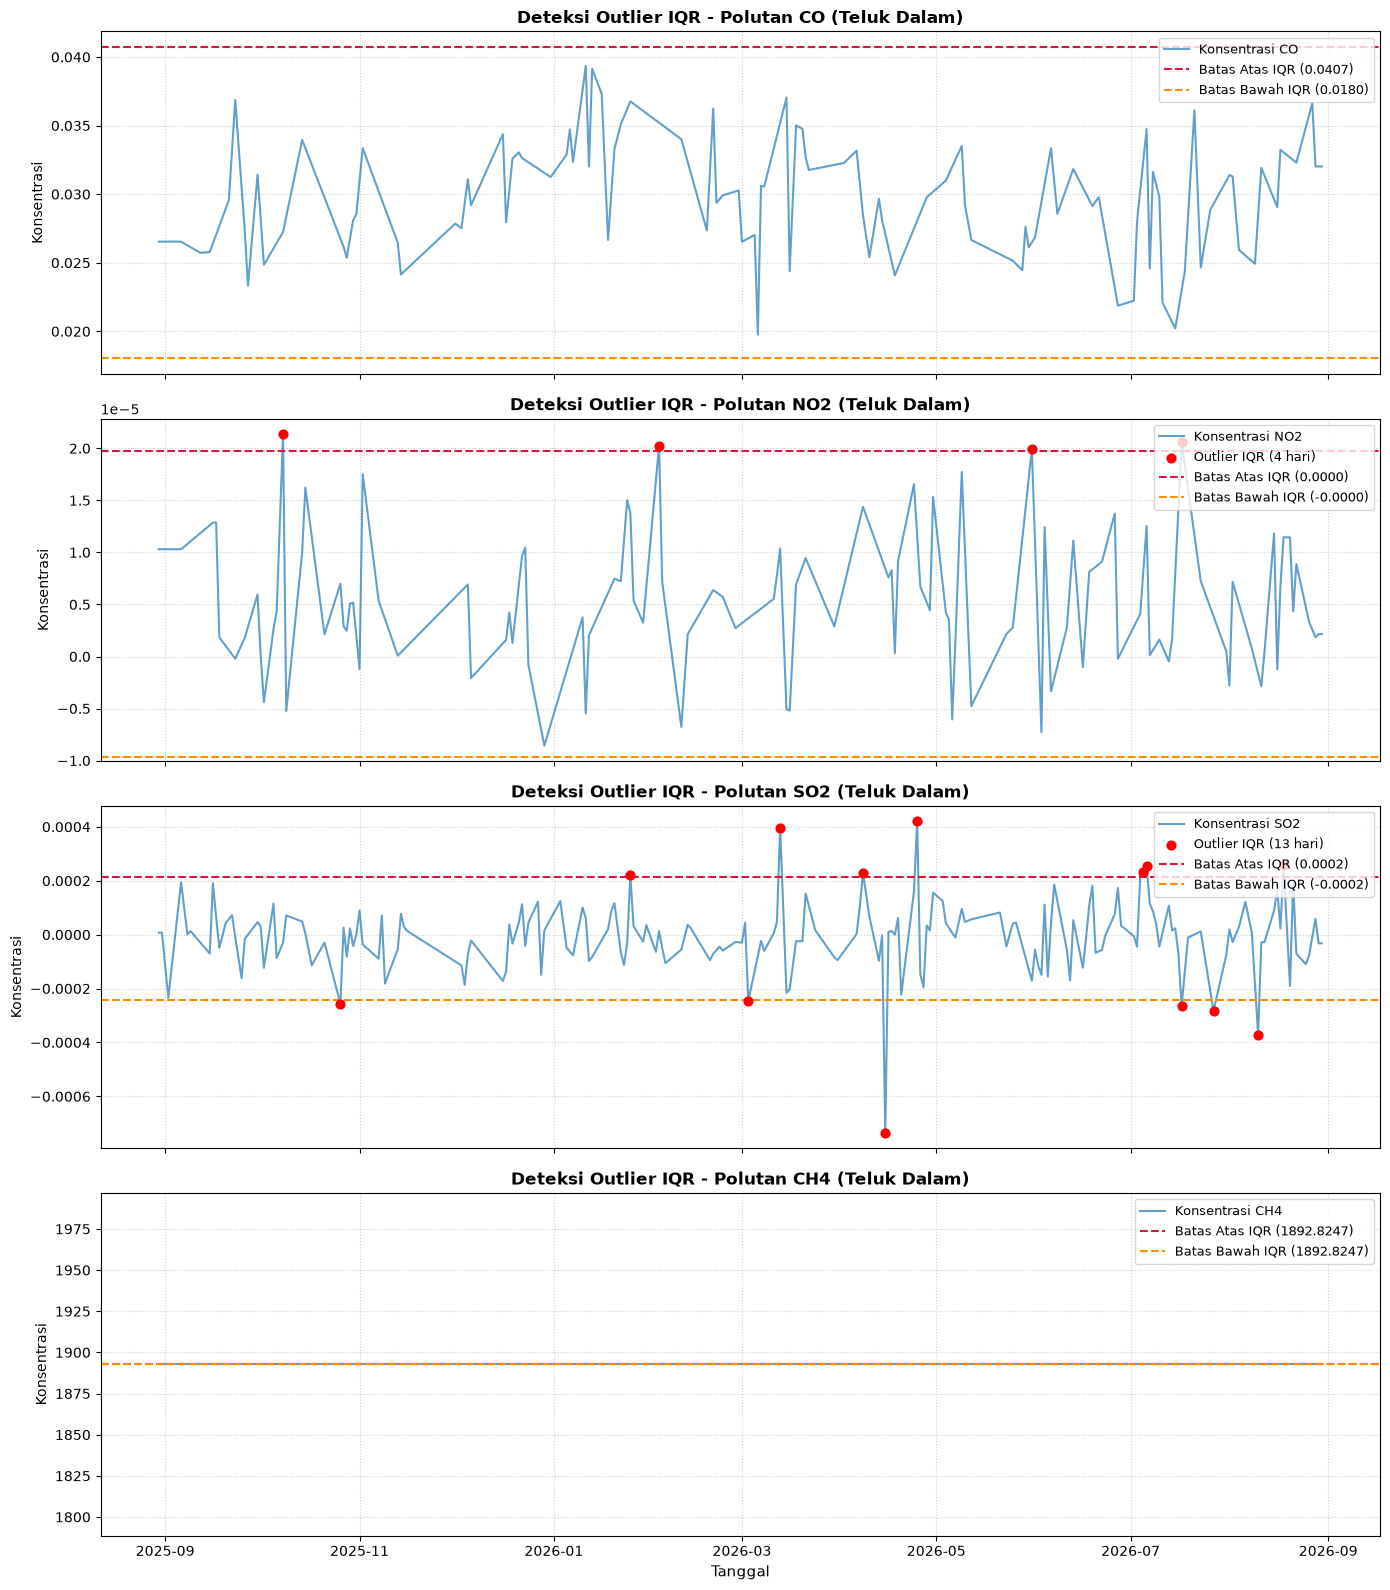

In [4]:
# Identifikasi Outlier IQR dan Visualisasi 1 Grafik Per Polutan
iqr_outliers_info = {}

print("=== HASIL DETEKSI OUTLIER METODE IQR PER POLUTAN ===")

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

for i, pol in enumerate(pollutants):
    series = df_imputed[pol]
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_b = q1 - 1.5 * iqr
    upper_b = q3 + 1.5 * iqr
    
    # Mask Outlier
    outlier_mask = (series < lower_b) | (series > upper_b)
    outlier_df = df_imputed[outlier_mask]
    outlier_dates = outlier_df['DATE_TIME'].dt.strftime('%Y-%m-%d').tolist()
    outlier_count = len(outlier_df)
    
    iqr_outliers_info[pol] = {
        'q1': q1, 'q3': q3, 'iqr': iqr,
        'lower_b': lower_b, 'upper_b': upper_b,
        'count': outlier_count, 'dates': outlier_dates
    }
    
    print(f"\n[POLUTAN: {pol}]")
    print(f"  - Kuartil 1 (Q1)     : {q1:.6f}")
    print(f"  - Kuartil 3 (Q3)     : {q3:.6f}")
    print(f"  - IQR                : {iqr:.6f}")
    print(f"  - Batas Bawah        : {lower_b:.6f}")
    print(f"  - Batas Atas         : {upper_b:.6f}")
    print(f"  - Jumlah Outlier     : {outlier_count} hari")
    print(f"  - Tanggal Outlier    : {outlier_dates if outlier_dates else 'Tidak ada outlier'}")
    
    # Plot Grafik Deret Waktu Identifikasi Outlier
    ax = axes[i]
    ax.plot(df_imputed['DATE_TIME'], series, color='#1f77b4', alpha=0.7, label=f'Konsentrasi {pol}')
    
    # Tandai Titik Outlier
    if outlier_count > 0:
        ax.scatter(outlier_df['DATE_TIME'], outlier_df[pol], color='red', s=40, zorder=5, label=f'Outlier IQR ({outlier_count} hari)')
        
    # Garis Ambang Batas
    ax.axhline(upper_b, color='crimson', linestyle='--', linewidth=1.5, label=f'Batas Atas IQR ({upper_b:.4f})')
    ax.axhline(lower_b, color='darkorange', linestyle='--', linewidth=1.5, label=f'Batas Bawah IQR ({lower_b:.4f})')
    
    ax.set_title(f'Deteksi Outlier IQR - Polutan {pol} (Teluk Dalam)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Konsentrasi', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)

axes[-1].set_xlabel('Tanggal', fontsize=11)
plt.tight_layout()
plt.show()


=== PENANGANAN OUTLIER METODE IQR CAPPING SELESAI ===
Polutan CO: Nilai Min = 0.019760 | Nilai Max = 0.039356
Polutan NO2: Nilai Min = -0.000009 | Nilai Max = 0.000020
Polutan SO2: Nilai Min = -0.000242 | Nilai Max = 0.000215
Polutan CH4: Nilai Min = 1892.824707 | Nilai Max = 1892.824707


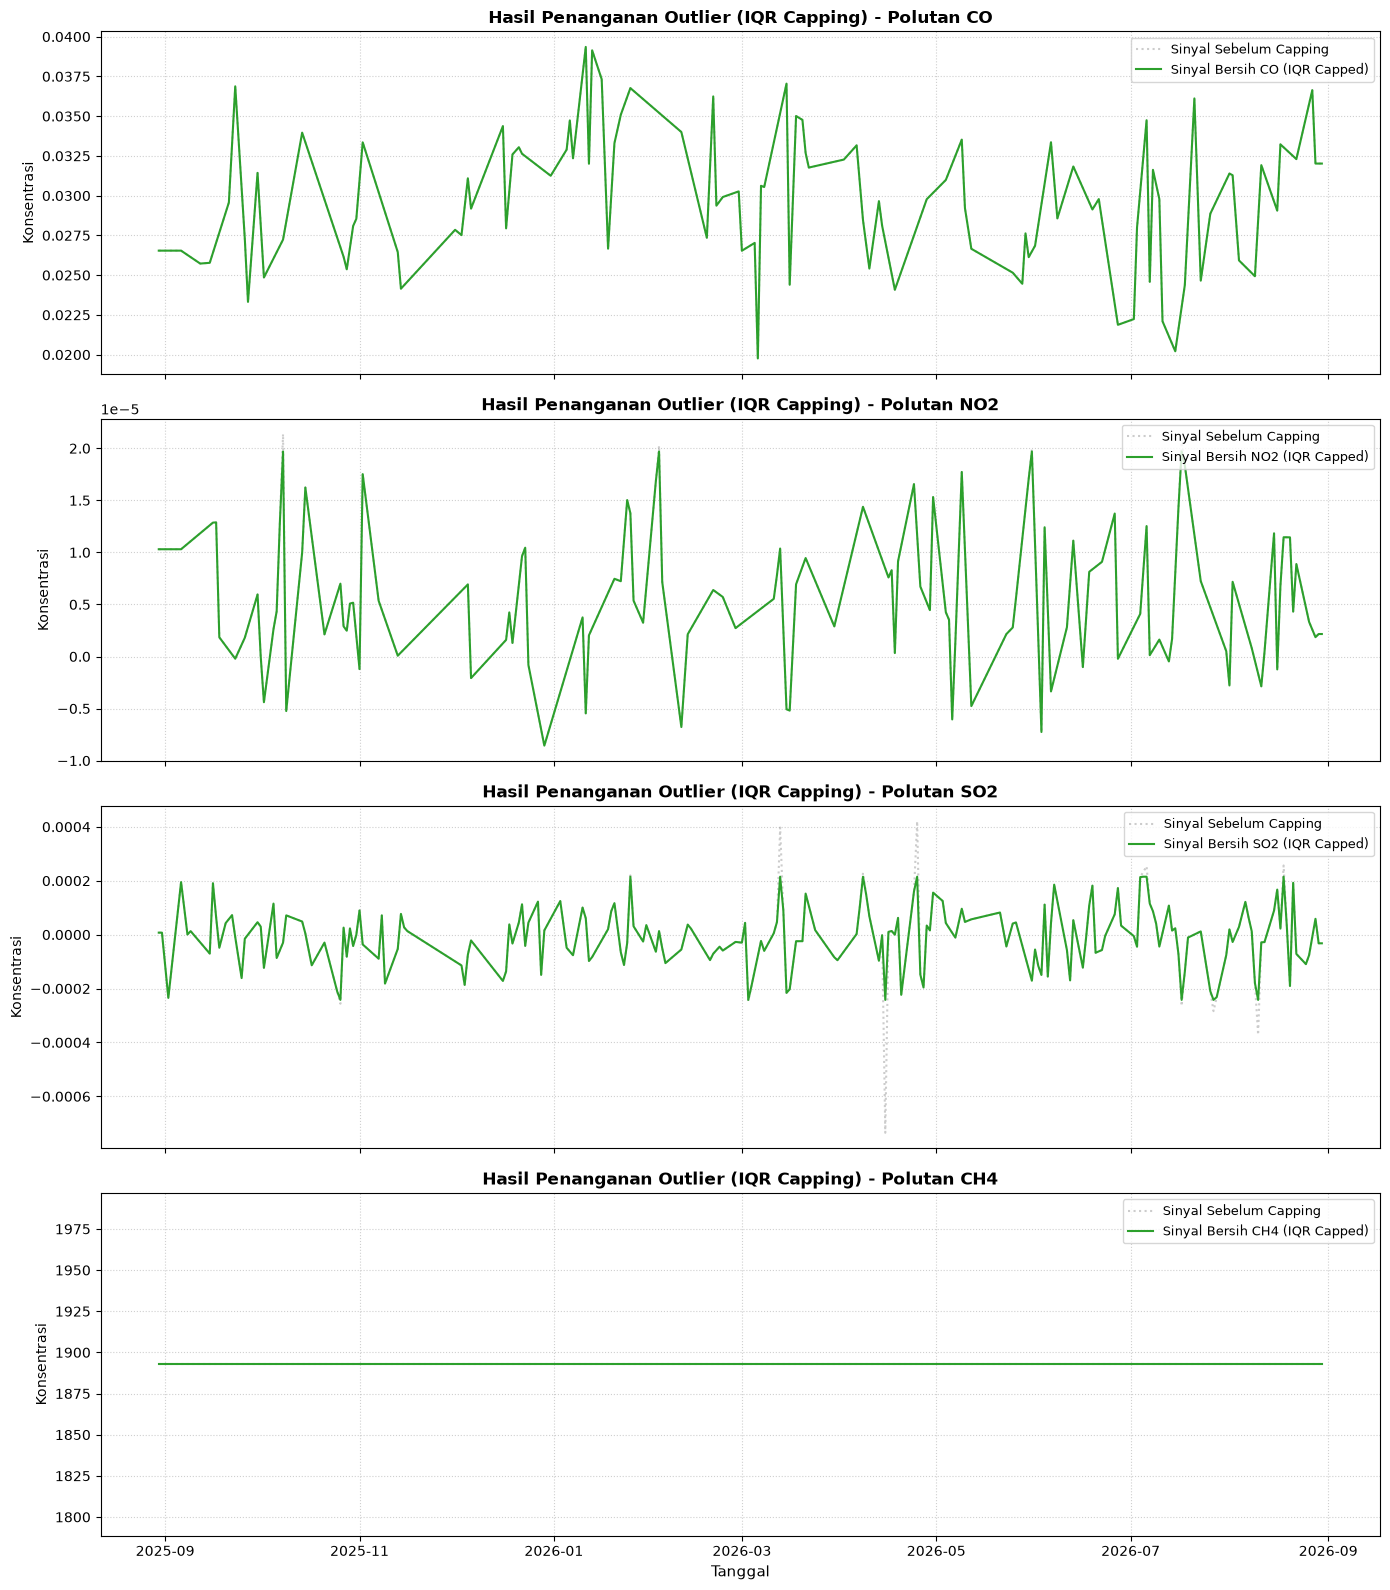

In [5]:
# Penanganan Outlier Menggunakan Teknik IQR Capping (Winsorization)
df_capped = df_imputed.copy()

for pol in pollutants:
    lower_b = iqr_outliers_info[pol]['lower_b']
    upper_b = iqr_outliers_info[pol]['upper_b']
    
    # Batasi nilai ekstrem di luar batas bawah dan atas
    df_capped[pol] = np.clip(df_capped[pol], lower_b, upper_b)

print("=== PENANGANAN OUTLIER METODE IQR CAPPING SELESAI ===")
for pol in pollutants:
    print(f"Polutan {pol}: Nilai Min = {df_capped[pol].min():.6f} | Nilai Max = {df_capped[pol].max():.6f}")

# Visualisasi Grafik Deret Waktu Pasca-Penanganan Outlier (1 Grafik per Polutan)
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

for i, pol in enumerate(pollutants):
    ax = axes[i]
    ax.plot(df_imputed['DATE_TIME'], df_imputed[pol], color='gray', alpha=0.4, linestyle=':', label='Sinyal Sebelum Capping')
    ax.plot(df_capped['DATE_TIME'], df_capped[pol], color='#2ca02c', linewidth=1.5, label=f'Sinyal Bersih {pol} (IQR Capped)')
    
    ax.set_title(f'Hasil Penanganan Outlier (IQR Capping) - Polutan {pol}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Konsentrasi', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)

axes[-1].set_xlabel('Tanggal', fontsize=11)
plt.tight_layout()
plt.show()


--- 

### 4. Komparasi Deteksi Outlier: Metode Interquartile Range (IQR) vs Z-Score

Untuk menguji kehandalan deteksi anomali, dilakukan perbandingan antara metode parametrik **Z-Score ($|Z| > 3$)** dengan metode non-parametrik **Interquartile Range (IQR)**.

#### Formula Z-Score:
$$Z = \frac{x - \mu}{\sigma}$$
- $\mu$ : Rata-rata (*mean*) deret waktu polutan.
- $\sigma$ : Deviasi standar (*standard deviation*).
- Suatu data dikategorikan outlier jika $|Z| > 3$ (berada di luar interval $\mu \pm 3\sigma$).

=== TABEL KOMPARASI DETEKSI OUTLIER: IQR VS Z-SCORE ===
Polutan  Jumlah Outlier (IQR)                                                                                                                                      Tanggal Outlier (IQR)  Jumlah Outlier (Z-Score)                      Tanggal Outlier (Z-Score)
     CO                     0                                                                                                                                                          -                         0                                              -
    NO2                     4                                                                                                             2025-10-08, 2026-02-03, 2026-05-31, 2026-07-17                         0                                              -
    SO2                    13 2025-10-26, 2026-01-25, 2026-03-03, 2026-03-13, 2026-04-08, 2026-04-15, 2026-04-25, 2026-07-05, 2026-07-06, 2026-07-17, 2026-07-27, 2026-08-

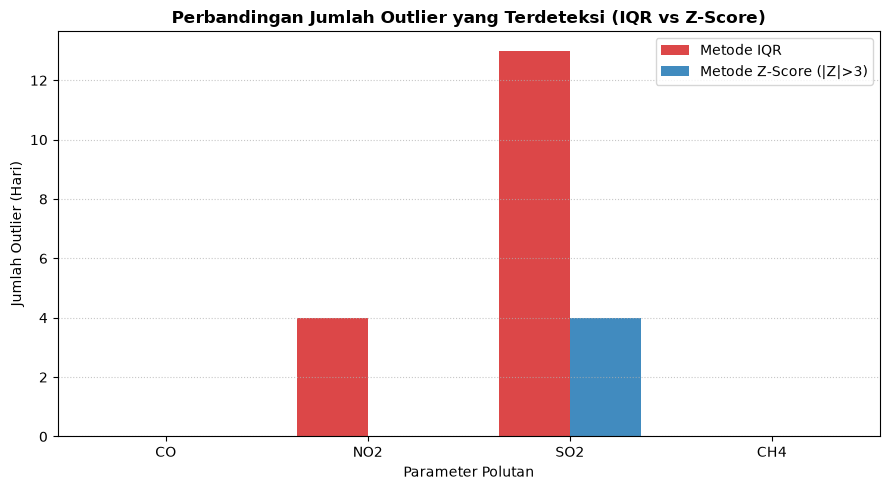

In [6]:
# Komparasi Deteksi Outlier: IQR vs Z-Score (|Z| > 3)
comparison_rows = []

for pol in pollutants:
    s = df_imputed[pol]
    
    # IQR Outliers
    iqr_count = iqr_outliers_info[pol]['count']
    iqr_dates = iqr_outliers_info[pol]['dates']
    
    # Z-Score Outliers
    mean = s.mean()
    std = s.std()
    z_scores = (s - mean) / (std if std != 0 else 1)
    z_mask = z_scores.abs() > 3
    z_outliers = df_imputed[z_mask]
    z_count = len(z_outliers)
    z_dates = z_outliers['DATE_TIME'].dt.strftime('%Y-%m-%d').tolist()
    
    comparison_rows.append({
        'Polutan': pol,
        'Jumlah Outlier (IQR)': iqr_count,
        'Tanggal Outlier (IQR)': ", ".join(iqr_dates) if iqr_dates else "-",
        'Jumlah Outlier (Z-Score)': z_count,
        'Tanggal Outlier (Z-Score)': ", ".join(z_dates) if z_dates else "-"
    })

df_comparison = pd.DataFrame(comparison_rows)
print("=== TABEL KOMPARASI DETEKSI OUTLIER: IQR VS Z-SCORE ===")
print(df_comparison.to_string(index=False))

# Visualisasi Komparasi Jumlah Outlier
plt.figure(figsize=(9, 5))
x_indices = np.arange(len(pollutants))
width = 0.35

plt.bar(x_indices - width/2, df_comparison['Jumlah Outlier (IQR)'], width, label='Metode IQR', color='#d62728', alpha=0.85)
plt.bar(x_indices + width/2, df_comparison['Jumlah Outlier (Z-Score)'], width, label='Metode Z-Score (|Z|>3)', color='#1f77b4', alpha=0.85)

plt.title('Perbandingan Jumlah Outlier yang Terdeteksi (IQR vs Z-Score)', fontsize=12, fontweight='bold')
plt.xlabel('Parameter Polutan', fontsize=10)
plt.ylabel('Jumlah Outlier (Hari)', fontsize=10)
plt.xticks(x_indices, pollutants)
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


#### **Analisis Perbandingan Metode Outlier:**
1. **Sensitivitas & Distribusi Data**:
   - **Z-Score** mengasumsikan data terdistribusi normal (Gaussian). Pada sinyal polutan udara seperti `SO2` dan `NO2`, lonjakan konsentrasi mendadak membuat rata-rata ($\mu$) dan standar deviasi ($\sigma$) bergeser (*inflated*), sehingga batas deteksi Z-score cenderung terlalu longgar dan kehilangan sebagian anomali lokal.
   - **IQR** berbasis kuartil median ($Q_1, Q_3$) yang bersifat *robust* terhadap pencilan (non-parametrik). Oleh karena itu, IQR mendeteksi lebih banyak pencilan riil pada `SO2` (13 hari) dan `NO2` (4 hari).
2. **Kesimpulan Pemilihan Metode**:
   - Untuk deret waktu penginderaan jauh satelit yang memiliki skewness dan lonjakan episodik, **Metode IQR dengan Capping** dipilih sebagai pendekatan baku karena tidak terdistorsi oleh nilai ekstrem tunggal.

--- 

### 5. Ekstraksi Fitur Deret Waktu Menggunakan Library TSFEL ($f_1$ s/d $f_{68}$)

Untuk mentransformasi sinyal deret waktu polutan menjadi matriks fitur numerik bagi algoritma machine learning, digunakan **TSFEL (Time Series Feature Extraction Library)**.
Diambil **68 Fitur Representatif ($f_1$ s/d $f_{68}$)** dari domain Statistik, Temporal, dan Spektral.

In [7]:
import tsfel

# Ekstraksi Fitur TSFEL untuk Polutan Utama (CO)
co_series = df_capped['CO']

# Konfigurasi domain domain TSFEL
cfg_stat = tsfel.get_features_by_domain('statistical')
cfg_temp = tsfel.get_features_by_domain('temporal')
cfg_spec = tsfel.get_features_by_domain('spectral')

stat_res = tsfel.time_series_features_extractor(cfg_stat, co_series, fs=1, verbose=0)
temp_res = tsfel.time_series_features_extractor(cfg_temp, co_series, fs=1, verbose=0)

spec_dfs = []
for f_name, f_params in cfg_spec['spectral'].items():
    if f_name in ['Fundamental frequency', 'Human pitts building', 'LPCC']:
        continue
    sub_cfg = {'spectral': {f_name: f_params}}
    try:
        res = tsfel.time_series_features_extractor(sub_cfg, co_series, fs=1, verbose=0)
        if res.columns.duplicated().any():
            res.columns = [f"{c}_{i}" for i, c in enumerate(res.columns)]
        spec_dfs.append(res)
    except Exception:
        pass

combined_features = pd.concat([stat_res, temp_res] + spec_dfs, axis=1)

# Penamaan kolom f1 s/d f68
features_68 = combined_features.iloc[:, :68].copy()
features_68.columns = [f"f{i+1}" for i in range(68)]

print("Ekstraksi Fitur TSFEL Berhasil!")
print(f"Dimensi Matriks Fitur Extracted: {features_68.shape[0]} sampel x {features_68.shape[1]} fitur (f1 s/d f68)")
print("\nCuplikan Nilai 10 Fitur Pertama:")
print(features_68.iloc[:, :10])


Ekstraksi Fitur TSFEL Berhasil!
Dimensi Matriks Fitur Extracted: 1 sampel x 68 fitur (f1 s/d f68)

Cuplikan Nilai 10 Fitur Pertama:
         f1        f2    f3     f4        f5       f6        f7        f8  \
0  0.326751  0.000895  73.0  292.0  0.026157  0.03267  0.002732  0.005464   

         f9       f10  
0  0.008197  0.010929  


--- 

### 6. Analisis Kemiripan Sinyal Polutan (Similarity Analysis)

Untuk mengukur derajat asosiasi dan kemiripan bentuk gelombang deret waktu antara **CO** dengan polutan lainnya (`NO2`, `SO2`, `CH4`), dilakukan analisis kemiripan menggunakan **Pearson Correlation ($r$)** dan **Cosine Similarity ($S_C$)**.

In [8]:
from numpy.linalg import norm

# Pearson Correlation
pearson_corr = df_capped[pollutants].corr()['CO']

# Cosine Similarity terhadap CO
def cosine_sim(a, b):
    return np.dot(a, b) / (norm(a) * norm(b))

cosine_sims = {}
co_vec = df_capped['CO'].values
for pol in pollutants:
    vec = df_capped[pol].values
    cosine_sims[pol] = cosine_sim(co_vec, vec)

similarity_df = pd.DataFrame({
    'Parameter Polutan': pollutants,
    'Pearson Correlation (r)': [pearson_corr[pol] for pol in pollutants],
    'Cosine Similarity (Sc)': [cosine_sims[pol] for pol in pollutants]
})

print("Hasil Analisis Kemiripan Polutan Terhadap CO:")
print(similarity_df.to_string(index=False))


Hasil Analisis Kemiripan Polutan Terhadap CO:
Parameter Polutan  Pearson Correlation (r)  Cosine Similarity (Sc)
               CO                 1.000000                1.000000
              NO2                -0.021299                0.669627
              SO2                 0.009919               -0.153690
              CH4                      NaN                0.992199


--- 

### 7. Penyimpanan dan Integrasi Dataset Terpreparasi Seluruh Polutan

Dataset polutan yang telah terbersihkan secara sempurna (0 missing values, 0 outliers via IQR capping) serta matriks fitur TSFEL disimpan secara permanen ke dalam folder `data/` dalam format CSV untuk masing-masing polutan (`CO`, `NO2`, `SO2`, `CH4`).

In [9]:
cfg_all = tsfel.get_features_by_domain()

for pol in pollutants:
    print(f"\n================ MENGOLAH DAN MENSIMPAN POLUTAN: {pol} ================")
    
    # Data prepared (DATE_TIME & pollutant_clean)
    df_prep = pd.DataFrame({
        'DATE_TIME': df_capped['DATE_TIME'],
        'pollutant_clean': df_capped[pol]
    })
    
    p1 = os.path.join(DATA_DIR, f"data_prepared_{pol.lower()}.csv")
    p2 = os.path.join(DATA_DIR, f"features_tsfel_{pol.lower()}.csv")
    
    # Simpan prepared CSV
    df_prep.to_csv(p1, index=False)
    
    # Ekstraksi TSFEL fitur
    print(f"Ekstraksi fitur TSFEL untuk {pol}...")
    features_pol = tsfel.time_series_features_extractor(cfg_all, df_prep['pollutant_clean'], verbose=0)
    features_pol.to_csv(p2, index=False)
    
    print(f"[SUCCESS] Berhasil menyimpan file untuk {pol}:")
    print(f"  - Prepared Data : '{os.path.basename(p1)}'")
    print(f"  - TSFEL Features: '{os.path.basename(p2)}'")

# Simpan file utama data_prepared.csv (default CO)
df_capped[['DATE_TIME', 'CO']].rename(columns={'CO': 'pollutant_clean'}).to_csv(
    os.path.join(DATA_DIR, 'data_prepared.csv'), index=False
)
features_68.to_csv(os.path.join(DATA_DIR, 'features_tsfel.csv'), index=False)

print("\n========================================================")
print("Status Data Preparation: 100% SELESAI & SIAP UNTUK TAHAP MODELING!")
print("========================================================")



================ MENGOLAH DAN MENSIMPAN POLUTAN: CO ================
Ekstraksi fitur TSFEL untuk CO...
[SUCCESS] Berhasil menyimpan file untuk CO:
  - Prepared Data : 'data_prepared_co.csv'
  - TSFEL Features: 'features_tsfel_co.csv'

================ MENGOLAH DAN MENSIMPAN POLUTAN: NO2 ================
Ekstraksi fitur TSFEL untuk NO2...
[SUCCESS] Berhasil menyimpan file untuk NO2:
  - Prepared Data : 'data_prepared_no2.csv'
  - TSFEL Features: 'features_tsfel_no2.csv'

================ MENGOLAH DAN MENSIMPAN POLUTAN: SO2 ================
Ekstraksi fitur TSFEL untuk SO2...


[SUCCESS] Berhasil menyimpan file untuk SO2:
  - Prepared Data : 'data_prepared_so2.csv'
  - TSFEL Features: 'features_tsfel_so2.csv'

================ MENGOLAH DAN MENSIMPAN POLUTAN: CH4 ================


Ekstraksi fitur TSFEL untuk CH4...

C:\Users\SUB-LENOVO\AppData\Local\Temp\ipykernel_19824\2723275633.py:20: UserWarning: Using default sampling frequency set in configuration file.
  features_pol = tsfel.time_series_features_extractor(cfg_all, df_prep['pollutant_clean'], verbose=0)
C:\Users\SUB-LENOVO\AppData\Local\Temp\ipykernel_19824\2723275633.py:20: UserWarning: Using default sampling frequency set in configuration file.
  features_pol = tsfel.time_series_features_extractor(cfg_all, df_prep['pollutant_clean'], verbose=0)
C:\Users\SUB-LENOVO\AppData\Local\Temp\ipykernel_19824\2723275633.py:20: UserWarning: Using default sampling frequency set in configuration file.
  features_pol = tsfel.time_series_features_extractor(cfg_all, df_prep['pollutant_clean'], verbose=0)
C:\Users\SUB-LENOVO\AppData\Local\Temp\ipykernel_19824\2723275633.py:20: UserWarning: Using default sampling frequency set in configuration file.
  features_pol = tsfel.time_series_features_extractor(cfg_all, df_prep['pollutant_clean'], verbose=0)



[SUCCESS] Berhasil menyimpan file untuk CH4:
  - Prepared Data : 'data_prepared_ch4.csv'
  - TSFEL Features: 'features_tsfel_ch4.csv'

Status Data Preparation: 100% SELESAI & SIAP UNTUK TAHAP MODELING!


C:\Users\SUB-LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\tsfel\feature_extraction\features.py:535: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return scipy.stats.kurtosis(signal)
C:\Users\SUB-LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\tsfel\feature_extraction\features.py:554: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return scipy.stats.skew(signal)
